# Phase 5: Classical Machine Learning Baseline


In [1]:
!pip install pandas scikit-learn matplotlib seaborn huggingface_hub


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

splits_df = pd.read_csv("resume_metadata_split.csv")
nlp_df = pd.read_csv("nlp_processed_resumes.csv")

df = pd.merge(nlp_df, splits_df[['filename', 'split']], on='filename', how='inner')

train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

Train size: 1726, Val size: 369, Test size: 371


In [3]:
print("Extracting TF-IDF Features...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train = tfidf.fit_transform(train_df['lemmatized_text'].fillna(""))
X_val = tfidf.transform(val_df['lemmatized_text'].fillna(""))
X_test = tfidf.transform(test_df['lemmatized_text'].fillna(""))

y_train = train_df['category']
y_val = val_df['category']
y_test = test_df['category']

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

Extracting TF-IDF Features...


Vocabulary size: 10000


In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n--- Evaluating {model_name} ---")
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (Macro): {prec:.4f}")
    print(f"Recall (Macro):    {rec:.4f}")
    print(f"F1 Score (Macro):  {f1:.4f}")
    
    return y_pred

def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title, fontsize=16)
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [5]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

Training Logistic Regression...



--- Evaluating Logistic Regression ---
Accuracy:  0.6658
Precision (Macro): 0.6773
Recall (Macro):    0.6505
F1 Score (Macro):  0.6487


In [6]:
print("Training Linear SVM...")
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)

svm_preds = evaluate_model(svm_model, X_test, y_test, "Linear SVM")

Training Linear SVM...



--- Evaluating Linear SVM ---
Accuracy:  0.7008
Precision (Macro): 0.7076
Recall (Macro):    0.6741
F1 Score (Macro):  0.6742


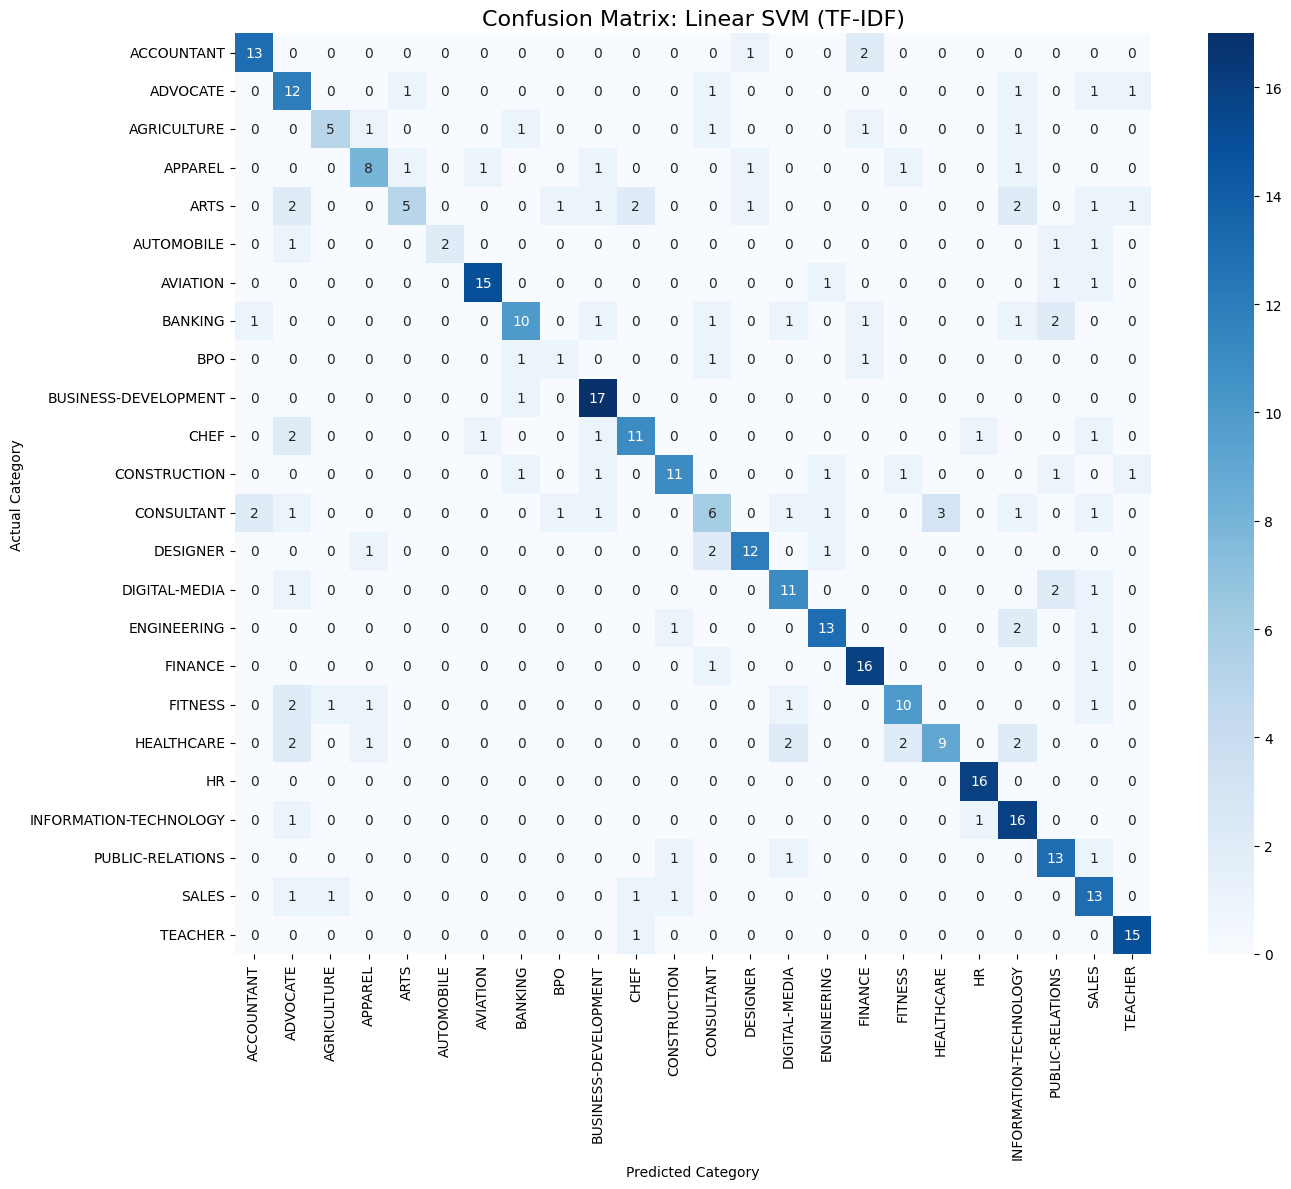


Detailed Classification Report (SVM):
                        precision    recall  f1-score   support

            ACCOUNTANT       0.81      0.81      0.81        16
              ADVOCATE       0.48      0.71      0.57        17
           AGRICULTURE       0.71      0.50      0.59        10
               APPAREL       0.67      0.57      0.62        14
                  ARTS       0.71      0.31      0.43        16
            AUTOMOBILE       1.00      0.40      0.57         5
              AVIATION       0.88      0.83      0.86        18
               BANKING       0.71      0.56      0.62        18
                   BPO       0.33      0.25      0.29         4
  BUSINESS-DEVELOPMENT       0.74      0.94      0.83        18
                  CHEF       0.73      0.65      0.69        17
          CONSTRUCTION       0.79      0.65      0.71        17
            CONSULTANT       0.46      0.33      0.39        18
              DESIGNER       0.80      0.75      0.77        16


In [7]:
classes = sorted(y_test.unique())
plot_confusion_matrix(y_test, svm_preds, classes, "Confusion Matrix: Linear SVM (TF-IDF)")

print("\nDetailed Classification Report (SVM):")
print(classification_report(y_test, svm_preds))